# Notebook 01 — Data Quality Audit

**Tier:** Pre-analytics  
**Purpose:** Document every data quality issue in the raw CSV before any cleaning.  
**Input:** `Data/ncr_ride_bookings.csv` (read-only, never modified)  
**Output:** `outputs/reports/data_quality_summary.csv`  
**Caveats:** All numeric ranges and distributions are observed from the actual data — no prior assumptions are encoded.

In [5]:
import warnings
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pathlib.Path('outputs/reports').mkdir(parents=True, exist_ok=True)
pathlib.Path('outputs/plots').mkdir(parents=True, exist_ok=True)

RAW_PATH = 'Data/ncr_ride_bookings.csv'
print(f'Reading: {RAW_PATH}')

Reading: Data/ncr_ride_bookings.csv


## 1. Raw Schema Overview

In [6]:
# Read all columns as strings to preserve raw values (no type coercion)
import os
os.chdir(r"D:\projects\Uber_Data_India_Analytics")

print("Working directory:", os.getcwd())
raw = pd.read_csv(RAW_PATH, dtype=str, keep_default_na=False)

print(f'Shape: {raw.shape}')
print(f'Columns ({len(raw.columns)}):')
for col in raw.columns:
    print(f'  {col!r:45s}  sample: {raw[col].iloc[0]!r}')

Working directory: D:\projects\Uber_Data_India_Analytics
Shape: (150000, 21)
Columns (21):
  'Date'                                         sample: '2024-03-23'
  'Time'                                         sample: '12:29:38'
  'Booking ID'                                   sample: '"CNR5884300"'
  'Booking Status'                               sample: 'No Driver Found'
  'Customer ID'                                  sample: '"CID1982111"'
  'Vehicle Type'                                 sample: 'eBike'
  'Pickup Location'                              sample: 'Palam Vihar'
  'Drop Location'                                sample: 'Jhilmil'
  'Avg VTAT'                                     sample: 'null'
  'Avg CTAT'                                     sample: 'null'
  'Cancelled Rides by Customer'                  sample: 'null'
  'Reason for cancelling by Customer'            sample: 'null'
  'Cancelled Rides by Driver'                    sample: 'null'
  'Driver Cancellation Reason

## 2. Row Count & Duplicates

In [7]:
EXPECTED = 150_000
actual = len(raw)
print(f'Expected rows : {EXPECTED:,}')
print(f'Actual rows   : {actual:,}')
if actual != EXPECTED:
    print(f'  ⚠ Deviation: {actual - EXPECTED:+,} rows')
else:
    print('  ✓ Row count matches expected.')

# Duplicate Booking IDs (raw string, before stripping quotes)
dup_ids = raw['Booking ID'].duplicated()
print(f'\nDuplicate Booking IDs: {dup_ids.sum()}')
if dup_ids.sum() > 0:
    print(raw[dup_ids | raw['Booking ID'].isin(raw[dup_ids]['Booking ID'])][['Booking ID','Booking Status','Date']].head())

Expected rows : 150,000
Actual rows   : 150,000
  ✓ Row count matches expected.

Duplicate Booking IDs: 1233
       Booking ID Booking Status        Date
146  "CNR2687237"      Completed  2024-04-15
248  "CNR5380412"      Completed  2024-02-01
317  "CNR5071968"      Completed  2024-10-10
397  "CNR2290384"      Completed  2024-04-28
493  "CNR3466923"      Completed  2024-02-11


## 3. Triple-Quote Encoding Issue

In [8]:
print('Sample Booking ID values (raw):')
print(raw['Booking ID'].head(3).tolist())
print('\nSample Customer ID values (raw):')
print(raw['Customer ID'].head(3).tolist())

triple_quoted_bids = raw['Booking ID'].str.startswith('"""').sum()
triple_quoted_cids = raw['Customer ID'].str.startswith('"""').sum()
print(f'\nTriple-quoted Booking IDs : {triple_quoted_bids:,} / {len(raw):,}')
print(f'Triple-quoted Customer IDs: {triple_quoted_cids:,} / {len(raw):,}')

Sample Booking ID values (raw):
['"CNR5884300"', '"CNR1326809"', '"CNR8494506"']

Sample Customer ID values (raw):
['"CID1982111"', '"CID4604802"', '"CID9202816"']

Triple-quoted Booking IDs : 0 / 150,000
Triple-quoted Customer IDs: 0 / 150,000


## 4. "null" String vs True NaN

In [9]:
null_str_counts = (raw == 'null').sum().rename('null_string_count')
empty_counts = (raw == '').sum().rename('empty_count')
null_summary = pd.concat([null_str_counts, empty_counts], axis=1)
null_summary['total_missing'] = null_summary.sum(axis=1)
null_summary['missing_pct'] = (null_summary['total_missing'] / len(raw) * 100).round(1)
print('Missing value counts per column ("null" strings + empty strings):')
print(null_summary.sort_values('total_missing', ascending=False).to_string())

null_summary.to_csv('outputs/reports/data_quality_summary.csv')
print('\nSaved: outputs/reports/data_quality_summary.csv')

Missing value counts per column ("null" strings + empty strings):
                                   null_string_count  empty_count  total_missing  missing_pct
Incomplete Rides Reason                       141000            0         141000         94.0
Incomplete Rides                              141000            0         141000         94.0
Reason for cancelling by Customer             139500            0         139500         93.0
Cancelled Rides by Customer                   139500            0         139500         93.0
Cancelled Rides by Driver                     123000            0         123000         82.0
Driver Cancellation Reason                    123000            0         123000         82.0
Driver Ratings                                 57000            0          57000         38.0
Customer Rating                                57000            0          57000         38.0
Avg CTAT                                       48000            0          48000        

## 5. Null Alignment Validation

In [10]:
# Check structural null patterns against Booking Status
status_col = 'Booking Status'
check_cols = ['Booking Value', 'Ride Distance', 'Payment Method',
              'Driver Ratings', 'Customer Rating']

print('Non-null counts by Booking Status for post-outcome columns:')
for col in check_cols:
    mask_present = (raw[col] != 'null') & (raw[col] != '')
    tbl = raw[mask_present].groupby(status_col).size().rename(col)
    print(f'\n  {col}:')
    print(tbl.to_string())

print('\n--- VTAT null by status ---')
vtat_null = (raw['Avg VTAT'] == 'null') | (raw['Avg VTAT'] == '')
print(raw[vtat_null].groupby(status_col).size())

print('\n--- CTAT null by status ---')
ctat_null = (raw['Avg CTAT'] == 'null') | (raw['Avg CTAT'] == '')
print(raw[ctat_null].groupby(status_col).size())

Non-null counts by Booking Status for post-outcome columns:

  Booking Value:
Booking Status
Completed     93000
Incomplete     9000

  Ride Distance:
Booking Status
Completed     93000
Incomplete     9000

  Payment Method:
Booking Status
Completed     93000
Incomplete     9000

  Driver Ratings:
Booking Status
Completed    93000

  Customer Rating:
Booking Status
Completed    93000

--- VTAT null by status ---
Booking Status
No Driver Found    10500
dtype: int64

--- CTAT null by status ---
Booking Status
Cancelled by Customer    10500
Cancelled by Driver      27000
No Driver Found          10500
dtype: int64


## 6. Booking Status Distribution

Booking Status distribution:
                       count   pct
Booking Status                    
Completed              93000  62.0
Cancelled by Driver    27000  18.0
No Driver Found        10500   7.0
Cancelled by Customer  10500   7.0
Incomplete              9000   6.0


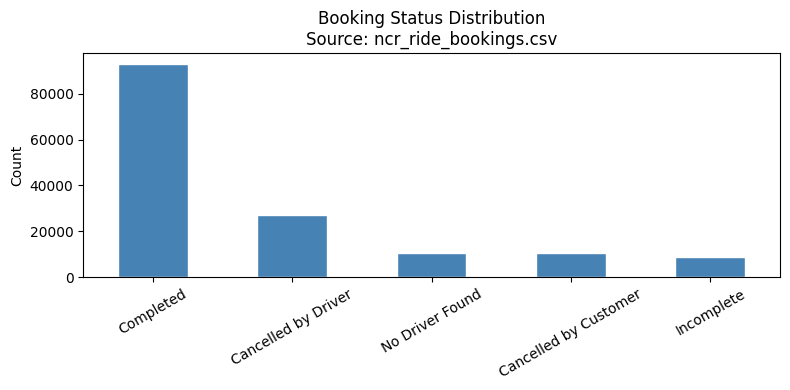

In [11]:
status_counts = raw['Booking Status'].value_counts()
status_pct = (status_counts / len(raw) * 100).round(1)
status_df = pd.DataFrame({'count': status_counts, 'pct': status_pct})
print('Booking Status distribution:')
print(status_df.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
status_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Booking Status Distribution\nSource: ncr_ride_bookings.csv')
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
fig.savefig('outputs/plots/01_booking_status.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Numeric Distributions (Observed — Not Assumed)

In [12]:
num_cols = ['Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance',
            'Driver Ratings', 'Customer Rating']

percentile_rows = []
for col in num_cols:
    vals = pd.to_numeric(raw[col].replace({'null': np.nan, '': np.nan}), errors='coerce').dropna()
    if len(vals) == 0:
        continue
    row = {
        'column': col, 'count': len(vals),
        'min': vals.min(), 'p25': vals.quantile(0.25), 'p50': vals.median(),
        'p75': vals.quantile(0.75), 'p95': vals.quantile(0.95), 'max': vals.max(),
        'mean': vals.mean().round(3)
    }
    percentile_rows.append(row)

perc_df = pd.DataFrame(percentile_rows).set_index('column')
print('Observed numeric distributions (from actual data):')
print(perc_df.round(2).to_string())
perc_df.to_csv('outputs/reports/numeric_distributions.csv')

Observed numeric distributions (from actual data):
                  count   min     p25     p50     p75      p95     max    mean
column                                                                        
Avg VTAT         139500   2.0    5.30    8.30   11.30    14.60    20.0    8.46
Avg CTAT         102000  10.0   21.60   28.80   36.80    43.40    45.0   29.15
Booking Value    102000  50.0  234.00  414.00  689.00  1224.00  4277.0  508.30
Ride Distance    102000   1.0   12.46   23.72   36.82    47.35    50.0   24.64
Driver Ratings    93000   3.0    4.10    4.30    4.60     4.90     5.0    4.23
Customer Rating   93000   3.0    4.20    4.50    4.80     5.00     5.0    4.40


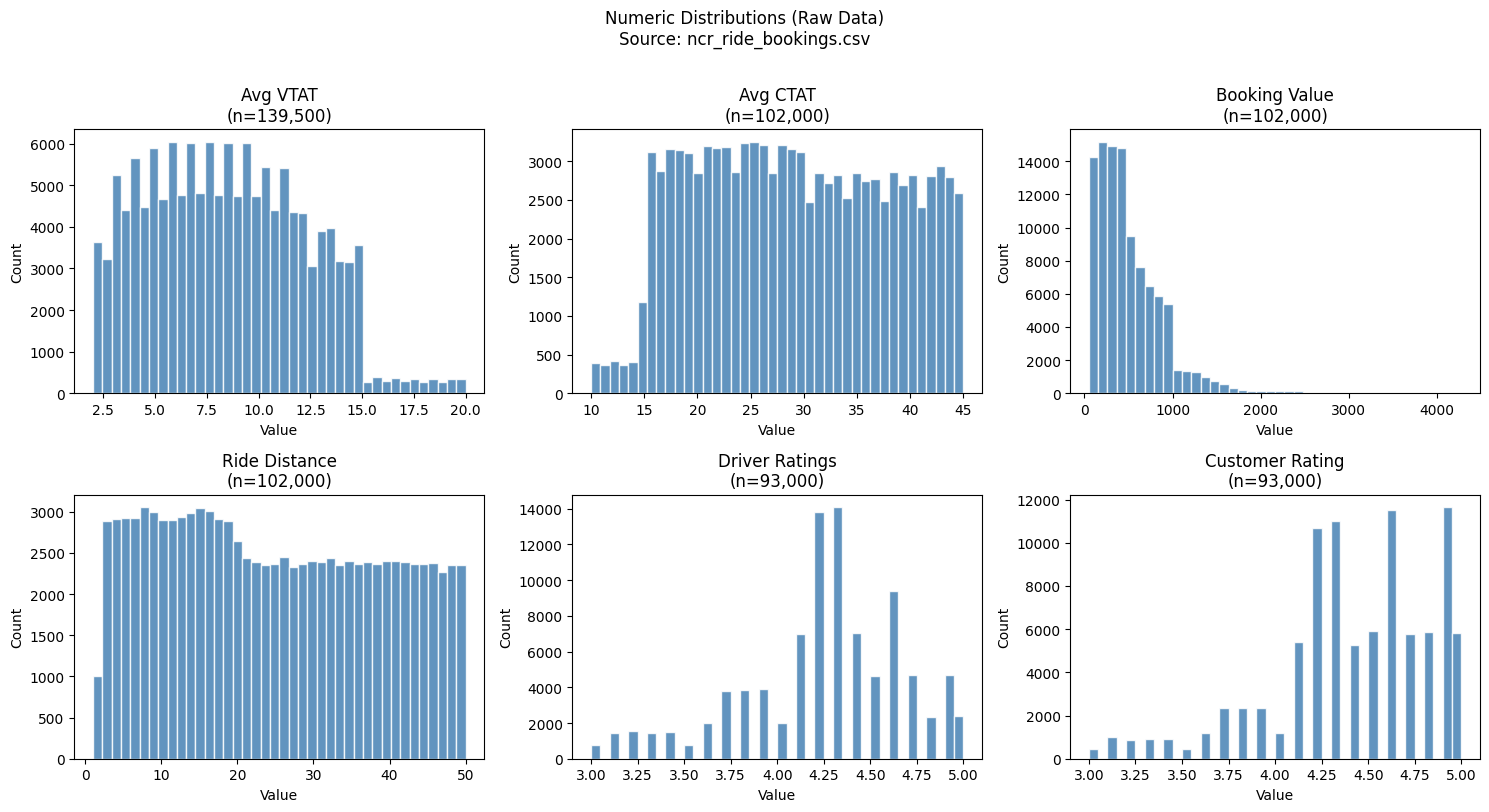

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    vals = pd.to_numeric(raw[col].replace({'null': np.nan, '': np.nan}), errors='coerce').dropna()
    ax = axes[i]
    ax.hist(vals, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(f'{col}\n(n={len(vals):,})')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
fig.suptitle('Numeric Distributions (Raw Data)\nSource: ncr_ride_bookings.csv', y=1.01)
plt.tight_layout()
fig.savefig('outputs/plots/01_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Categorical Cardinality

In [14]:
cat_cols = ['Vehicle Type', 'Payment Method', 'Reason for cancelling by Customer',
            'Driver Cancellation Reason', 'Incomplete Rides Reason']
for col in cat_cols:
    vals = raw[col][~raw[col].isin(['null', ''])]
    print(f'\n{col} ({vals.nunique()} unique, {len(vals):,} non-null):')
    print(vals.value_counts().to_string())


Vehicle Type (7 unique, 150,000 non-null):
Vehicle Type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449

Payment Method (5 unique, 102,000 non-null):
Payment Method
UPI            45909
Cash           25367
Uber Wallet    12276
Credit Card    10209
Debit Card      8239

Reason for cancelling by Customer (5 unique, 10,500 non-null):
Reason for cancelling by Customer
Wrong Address                                   2362
Change of plans                                 2353
Driver is not moving towards pickup location    2335
Driver asked to cancel                          2295
AC is not working                               1155

Driver Cancellation Reason (4 unique, 27,000 non-null):
Driver Cancellation Reason
Customer related issue                 6837
The customer was coughing/sick         6751
Personal & Car related issues          6726
More than permitted people in there  

## 9. Location Cardinality

In [15]:
print(f'Unique Pickup Locations : {raw["Pickup Location"].nunique()}')
print(f'Unique Drop Locations   : {raw["Drop Location"].nunique()}')
print(f'Unique routes (P→D pairs): {(raw["Pickup Location"] + " → " + raw["Drop Location"]).nunique()}')
print('\nTop 10 Pickup Locations:')
print(raw['Pickup Location'].value_counts().head(10).to_string())

Unique Pickup Locations : 176
Unique Drop Locations   : 176
Unique routes (P→D pairs): 30564

Top 10 Pickup Locations:
Pickup Location
Khandsa             949
Barakhamba Road     946
Saket               931
Badarpur            921
Pragati Maidan      920
Madipur             919
AIIMS               918
Mehrauli            915
Dwarka Sector 21    914
Pataudi Chowk       907


## 10. Date Range & Continuity

In [16]:
dates = pd.to_datetime(raw['Date'], errors='coerce')
print(f'Date min : {dates.min().date()}')
print(f'Date max : {dates.max().date()}')
months_present = dates.dt.to_period('M').unique()
print(f'Months present ({len(months_present)}): {sorted(str(m) for m in months_present)}')
if len(months_present) < 12:
    print('  ⚠ Some months missing from 2024 calendar year.')
else:
    print('  ✓ All 12 months of 2024 present.')

Date min : 2024-01-01
Date max : 2024-12-30
Months present (12): ['2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12']
  ✓ All 12 months of 2024 present.


## 11. Quality Issue Summary

| Issue | Affected Rows | Planned Fix |
|---|---|---|
| Triple-quoted Booking ID / Customer ID | All 150,000 | Strip `"""` in cleaning |
| `"null"` strings instead of true NaN | ~48,000–57,000 depending on column | Replace with `np.nan` |
| `Booking Value` / `Ride Distance` / `Payment Method` null for non-Completed | ~57,000 (structural) | Document as by-design; do not impute |
| `Driver Ratings` / `Customer Rating` null for non-Completed | ~57,000 (structural) | Document; do not impute |
| `Avg CTAT` null for No Driver Found + all cancellations | ~48,000 (structural) | Document; impute training median in ML pipeline only |
| Date/Time are separate string columns | All rows | Combine → `datetime` during cleaning |

## Limitations
- No driver ID field → cannot analyse individual driver behaviour.
- No cost fields (payout, commission, operating cost) → CAC, LTV, ROAS, contribution margin cannot be calculated.
- No acquisition channel field → customer origin is unknown.